# Audio Classification: MotoSense

Dataset processing and CNN/ViT pipeline for motorcycle engine classification.

Pipeline:
1. Data renaming
2. Train/val/test split
3. Preprocessing (Trim & Normalize) & Chunking (Sliding Window)
4. Augmentation (Training set only)
5. Log-Mel Spectrogram Extraction
6. Model Training & Evaluation

## 1. Library & Konfigurasi

In [29]:
import os, glob, shutil, random, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


from audiomentations import (
    Compose,
    AddGaussianNoise,
    LowPassFilter,
    BandPassFilter,
    ClippingDistortion,
    Gain,
    PitchShift,
    TimeStretch,
    Shift,
    PolarityInversion,
    OneOf
)

import matplotlib.pyplot as plt
import seaborn as sns


import matplotlib.gridspec as gridspec
import tensorflow_hub as hub
import numpy as np
import os
import glob
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
from sklearn.utils.class_weight import compute_class_weight

# ── Konfigurasi ──────────────────────────────────────────────
CLASSES       = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt",
                 "Piston", "Tensioner", "Slider", "Roller", "Face-Drive"]
BASE_DIR      = "Dataset"
TARGET_SR     = 16000
DURATION      = 2
TARGET_SAMPLES = TARGET_SR * DURATION  # 48.000
STRIDE_SAMPLES = int(TARGET_SR * 1.5)

# Mel-Spectrogram — shape output: (128, 128)
N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 375  # 48000 / 375 = 128 frame tepat

# Augmentasi
AUG_TARGET   = 200  # minimal per kelas di training

# Training
BATCH_SIZE   = 8
EPOCHS       = 100
SEED         = 42

# ── Folder paths ─────────────────────────────────────────────
PATHS = {
    "raw"         : os.path.join(BASE_DIR, "part-rusak"),
    "rename"      : os.path.join(BASE_DIR, "rename"),
    "split_orig"  : os.path.join(BASE_DIR, "split_original"),
    "prep_train"  : os.path.join(BASE_DIR, "preprocesed", "train"),
    "prep_val"    : os.path.join(BASE_DIR, "preprocesed", "val"),
    "prep_test"   : os.path.join(BASE_DIR, "preprocesed", "test"),
    "aug_train"   : os.path.join(BASE_DIR, "augmented", "train"),
    "features"    : os.path.join(BASE_DIR, "features"),
    "models"      : "models",
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

# print(f"TensorFlow  : {tf.__version__}")
# print(f"GPU         : {tf.config.list_physical_devices('GPU') or 'CPU'}")
# print(f"Target shape: ({N_MELS}, {TARGET_SAMPLES // HOP_LENGTH}, 1)")

## 2. Rename File

In [30]:
for cls in CLASSES:
    src = os.path.join(PATHS['raw'], cls)
    dst = os.path.join(PATHS['rename'], cls)
    os.makedirs(dst, exist_ok=True)
    files = sorted(f for f in os.listdir(src) if f.endswith(('.wav','.mp3','.m4a')))
    for i, f in enumerate(files, 1):
        ext = os.path.splitext(f)[1]
        shutil.copy(os.path.join(src, f),
                    os.path.join(dst, f"{cls.lower()}-{i:03d}{ext}"))
    print(f"  {cls:<15}: {len(files)} file")

print(f"\nDisimpan ke: {PATHS['rename']}")

  Clutch-Shoe    : 15 file
  Conecting-Rod  : 10 file
  Drive-Belt     : 20 file
  Piston         : 6 file
  Tensioner      : 8 file
  Slider         : 13 file
  Roller         : 19 file
  Face-Drive     : 9 file

Disimpan ke: Dataset/rename


## 3. Train/Val/Test Split

Split data awal untuk mencegah data leakage.

In [31]:
all_files, all_labels = [], []
for lbl, cls in enumerate(CLASSES):
    for f in glob.glob(os.path.join(PATHS['rename'], cls, '*.wav')):
        all_files.append(f)
        all_labels.append(lbl)

# Split: 70 / 15 / 15
X_tmp, X_test, y_tmp, y_test = train_test_split(
    all_files, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED)
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_tmp, y_tmp, test_size=0.176, stratify=y_tmp, random_state=SEED)

# Menyalin file asli ke masing-masing folder split
for name, files, labels in [("train", X_train, y_train_raw),
                              ("val",   X_val,   y_val_raw),
                              ("test",  X_test,  y_test)]:
    count = 0
    for f, l in zip(files, labels):
        cls = CLASSES[l]
        dst_dir = os.path.join(PATHS['split_orig'], name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))
        count += 1
    print(f"  {name:<6}: {count:>3} file disalin ke {os.path.join(PATHS['split_orig'], name)}")

print(f"\nTotal file asli: {len(all_files)}")

  train :  70 file disalin ke Dataset/split_original/train
  val   :  15 file disalin ke Dataset/split_original/val
  test  :  15 file disalin ke Dataset/split_original/test

Total file asli: 100


## 4. Preprocessing & Chunking

Sliding window chunking (3 detik) untuk tiap subset.

In [32]:
def preprocess(path):
    y, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    peak  = np.max(np.abs(y))
    return y / peak if peak > 0 else y

def chunk_and_save(src_base, out_base):
    total = 0
    for cls in CLASSES:
        src_dir = os.path.join(src_base, cls)
        dst_dir = os.path.join(out_base, cls)
        os.makedirs(dst_dir, exist_ok=True)
        
        files = glob.glob(os.path.join(src_dir, '*.wav'))
        for f in files:
            audio  = preprocess(f)
            base   = os.path.splitext(os.path.basename(f))[0]

            # Sliding window
            audio_len = len(audio)
            if audio_len < TARGET_SAMPLES:
                audio = np.tile(audio, int(np.ceil(TARGET_SAMPLES / audio_len)))
            chunks = [audio[i:i+TARGET_SAMPLES]
                      for i in range(0, len(audio)-TARGET_SAMPLES+1, STRIDE_SAMPLES)
                      if len(audio[i:i+TARGET_SAMPLES]) == TARGET_SAMPLES]
            for ci, chunk in enumerate(chunks):
                sf.write(os.path.join(dst_dir, f"{base}_c{ci}.wav"), chunk, TARGET_SR, subtype='PCM_16')
                total += 1
    return total

for subset, out_key in [("train", "prep_train"), ("val", "prep_val"), ("test", "prep_test")]:
    src_base = os.path.join(PATHS['split_orig'], subset)
    n = chunk_and_save(src_base, PATHS[out_key])
    print(f"  {subset:<6}: {n} chunks → {PATHS[out_key]}")

print("\nChunking selesai")

  train : 116 chunks → Dataset/preprocesed/train
  val   : 19 chunks → Dataset/preprocesed/val
  test  : 24 chunks → Dataset/preprocesed/test

Chunking selesai


## 5. Augmentation

Hanya diterapkan pada data training.

In [33]:
augment = Compose([
    # 1) Noise lingkungan / sensor
    OneOf([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.010, p=1.0),
        # Jika Anda punya noise folder, AddBackgroundNoise lebih bagus daripada GaussianNoise
        # AddBackgroundNoise(sounds_path="Dataset/noise", min_snr_in_db=5, max_snr_in_db=25, p=1.0),
    ], p=0.80),

    # 2) Distorsi mikrofon / jarak rekaman
    OneOf([
        LowPassFilter(min_cutoff_freq=2500, max_cutoff_freq=8000, p=1.0),
        BandPassFilter(min_center_freq=300, max_center_freq=6000, min_bandwidth_fraction=0.4, max_bandwidth_fraction=0.9, p=1.0),
        ClippingDistortion(max_percentile_threshold=5, p=1.0),
    ], p=0.45),

    # 3) Variasi volume
    Gain(min_gain_db=-10, max_gain_db=8, p=0.70),

    # 4) Posisi / timing perekaman
    Shift(min_shift=-0.15, max_shift=0.15, rollover=True, p=0.55),

    # 5) Variasi mesin yang sangat ringan
    TimeStretch(min_rate=0.95, max_rate=1.05, p=0.25),
    PitchShift(min_semitones=-1, max_semitones=1, p=0.15),

    # 6) Opsional, efek kecil
    PolarityInversion(p=0.10),
])

for cls in CLASSES:
    src_dir = os.path.join(PATHS['prep_train'], cls)
    dst_dir = os.path.join(PATHS['aug_train'], cls)
    os.makedirs(dst_dir, exist_ok=True)

    existing = glob.glob(os.path.join(src_dir, '*.wav'))
    if len(existing) == 0:
        print(f"  {cls:<15}: tidak ada file, dilewati")
        continue

    # Salin file asli
    for f in existing:
        shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))

    needed = max(0, AUG_TARGET - len(existing))

    for i in range(needed):
        src_file = random.choice(existing)
        y, _ = librosa.load(src_file, sr=TARGET_SR, mono=True)

        y_aug = augment(samples=y.astype(np.float32), sample_rate=TARGET_SR)

        # Samakan panjang
        if len(y_aug) < TARGET_SAMPLES:
            y_aug = np.pad(y_aug, (0, TARGET_SAMPLES - len(y_aug)))
        else:
            y_aug = y_aug[:TARGET_SAMPLES]

        out_path = os.path.join(dst_dir, f"aug_{i:05d}.wav")
        sf.write(out_path, y_aug, TARGET_SR, subtype='PCM_16')

    final = len(glob.glob(os.path.join(dst_dir, '*.wav')))
    print(f"  {cls:<15}: {len(existing):>3} asli → {final} total (+{needed} aug)")

print(f"\nDisimpan ke: {PATHS['aug_train']}")

  Clutch-Shoe    :  14 asli → 200 total (+186 aug)
  Conecting-Rod  :   7 asli → 200 total (+193 aug)
  Drive-Belt     :  24 asli → 200 total (+176 aug)
  Piston         :   4 asli → 200 total (+196 aug)
  Tensioner      :   9 asli → 200 total (+191 aug)
  Slider         :  24 asli → 200 total (+176 aug)
  Roller         :  23 asli → 200 total (+177 aug)
  Face-Drive     :  11 asli → 200 total (+189 aug)

Disimpan ke: Dataset/augmented/train


## 6. Feature Extraction (Log-Mel Spectrogram)

Konversi audio ke matriks 2D (128x128).

### Visualisasi Spectrogram

Sample perbandingan waveform dan spectrogram.

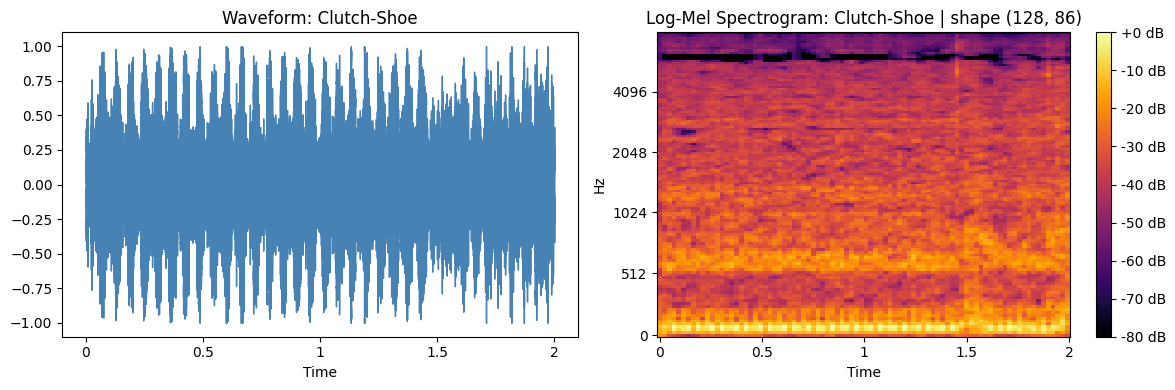

In [34]:
import random, matplotlib.pyplot as plt, librosa, librosa.display

sample_wavs = glob.glob(os.path.join(PATHS['aug_train'], '*', '*.wav'))
if sample_wavs:
    sample_path = random.choice(sample_wavs)
    cls_name    = os.path.basename(os.path.dirname(sample_path))
    y_s, sr_s   = librosa.load(sample_path, sr=TARGET_SR, mono=True)
    mel = librosa.feature.melspectrogram(y=y_s, sr=sr_s, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    db  = librosa.power_to_db(mel, ref=np.max)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    librosa.display.waveshow(y_s, sr=sr_s, ax=ax[0], color='steelblue')
    ax[0].set_title(f'Waveform: {cls_name}')
    img = librosa.display.specshow(db, sr=sr_s, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax[1], cmap='inferno')
    plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title(f'Log-Mel Spectrogram: {cls_name} | shape {db.shape}')
    plt.tight_layout(); plt.show()

In [35]:
# import numpy as np
# import librosa

# def extract_log_mel(wav_path):
#     y, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)
#     mel  = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
#     return librosa.power_to_db(mel, ref=np.max).astype(np.float32)

# FEAT = {
#     "train": (os.path.join(PATHS['features'], 'X_train.npy'), os.path.join(PATHS['features'], 'y_train.npy')),
#     "val"  : (os.path.join(PATHS['features'], 'X_val.npy'),   os.path.join(PATHS['features'], 'y_val.npy')),
#     "test" : (os.path.join(PATHS['features'], 'X_test.npy'),  os.path.join(PATHS['features'], 'y_test.npy')),
# }
# SRC_MAP = {
#     "train": PATHS['aug_train'],
#     "val"  : PATHS['prep_val'],
#     "test" : PATHS['prep_test'],
# }

# print("Ekstraksi Log-Mel Spectrogram...")
# for subset, (xp, yp) in FEAT.items():
#     if os.path.exists(xp):
#         print(f"  {subset}: cache ditemukan, skip")
#         continue
#     X_list, y_list = [], []
#     for lbl, cls in enumerate(CLASSES):
#         files = glob.glob(os.path.join(SRC_MAP[subset], cls, '*.wav'))
#         for f in files:
#             X_list.append(extract_log_mel(f))
#             y_list.append(lbl)
#     np.save(xp, np.array(X_list)); np.save(yp, np.array(y_list))
#     print(f"  {subset}: {len(X_list)} sampel tersimpan")

## 7. Load Features

In [36]:
# import numpy as np

# X_train = np.load(FEAT['train'][0])
# y_train = np.load(FEAT['train'][1])
# X_val   = np.load(FEAT['val'][0])
# y_val   = np.load(FEAT['val'][1])
# X_test  = np.load(FEAT['test'][0])
# y_test  = np.load(FEAT['test'][1])

# # Tambahkan channel dimension jika belum ada
# if X_train.ndim == 3:
#     X_train = X_train[..., np.newaxis]
#     X_val   = X_val[...,   np.newaxis]
#     X_test  = X_test[...,  np.newaxis]

# # Normalisasi per-sampel ke [0,1]
# def norm(X):
#     mn = X.min(axis=(1,2,3), keepdims=True)
#     mx = X.max(axis=(1,2,3), keepdims=True)
#     return (X - mn) / (mx - mn + 1e-8)

# X_train, X_val, X_test = norm(X_train), norm(X_val), norm(X_test)
# INPUT_SHAPE = X_train.shape[1:]

# print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
# print(f"X_val   : {X_val.shape}")
# print(f"X_test  : {X_test.shape}")
# print(f"INPUT_SHAPE : {INPUT_SHAPE}")

## 8. Arsitektur Model — CNN

CNN dipilih karena memperlakukan log-mel spectrogram seperti gambar:
- **Sumbu Y**: frekuensi (mel bands)
- **Sumbu X**: waktu (frames)
- Conv2D belajar pola frekuensi × waktu yang khas per jenis kerusakan

`GlobalAveragePooling2D` menggantikan Flatten untuk mengurangi parameter dan overfitting.

In [37]:
# import tensorflow as tf
# from tensorflow.keras import Sequential, layers, regularizers

# N_CLASSES = len(CLASSES)

# def build_cnn(input_shape, n_classes):
#     return Sequential([
#         layers.Input(shape=input_shape),
#         layers.Conv2D(16, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4)),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2,2)),
#         layers.Dropout(0.3),
        
#         layers.Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4)),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2,2)),
#         layers.Dropout(0.3),
        
#         layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4)),
#         layers.BatchNormalization(),
#         layers.GlobalAveragePooling2D(),
#         layers.Dropout(0.4),
        
#         layers.Dense(n_classes, activation='softmax')
#     ], name='motosense_cnn')

# model = build_cnn(INPUT_SHAPE, N_CLASSES)
# model.summary()

## Alternatif 2: MobileNetV2 (ImageNet Transfer Learning)

MobileNetV2 dilatih menggunakan jutaan gambar berwarna (RGB). Matriks Spectrogram kita hanya berukuran `(128, 128, 1)`.
Oleh karena itu, kita menggunakan layer `Lambda` untuk menduplikat Spectrogram tersebut menjadi `(128, 128, 3)` agar bisa diterima oleh MobileNetV2.


In [38]:
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras import models, layers
# import tensorflow as tf

# INPUT_SHAPE = X_train.shape[1:]  # (128, 128, 1)
# N_CLASSES   = len(CLASSES)

# def build_mobilenetv2(input_shape, n_classes):
#     # input_shape asli: (128, 128, 1)
#     inputs = layers.Input(shape=input_shape)
    
#     # 1. Duplikasi Channel 1 menjadi 3 (Grayscale to RGB)
#     # Menggunakan trik Concatenate (aman & stabil) untuk menggandakan channel 1 ke 3\n    x = layers.Concatenate()([inputs, inputs, inputs])
    
#     # 2. Muat kerangka MobileNetV2 tanpa layer klasifikasi ujungnya (include_top=False)
#     base_model = MobileNetV2(input_shape=(input_shape[0], input_shape[1], 3), include_top=False, weights='imagenet')
    
#     # Freeze seluruh arsitektur MobileNetV2 agar tidak merusak bobot yang sudah pintar
#     base_model.trainable = False
    
#     # 3. Lewatkan input kita ke dalam MobileNetV2
#     x = base_model(x, training=False)
    
#     # 4. Tambahkan layer klasifikasi khusus untuk 8 kelas mesin motor kita
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dropout(0.3)(x)
#     outputs = layers.Dense(n_classes, activation='softmax')(x)
    
#     model = models.Model(inputs, outputs, name='motosense_mobilenetv2')
#     return model

# # Panggil fungsi dan buat model
# model_mb2 = build_mobilenetv2(INPUT_SHAPE, len(CLASSES))
# model_mb2.summary()

# # Untuk menggunakan model ini pada proses Training (Bagian 9 di bawah), 
# # Anda cukup melakukan hal berikut:
# #
# # model_mb2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
# #                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# # 
# # history = model_mb2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, callbacks=callbacks, ...)


## Alternatif: Vision Transformer (ViT)

Compact ViT untuk perbandingan performa.

In [39]:
# import tensorflow as tf
# from tensorflow.keras import layers, Model

# def build_transformer(input_shape, n_classes, patch_size=16, embed_dim=32, num_heads=4, ff_dim=128, num_transformer_blocks=3):
#     """
#     Membangun arsitektur Compact Vision Transformer (ViT) untuk Spectrogram.
#     """
#     inputs = layers.Input(shape=input_shape)
    
#     # 1. Patch Extraction & Linear Projection
#     # Memotong citra 128x128 menjadi kotak-kotak berukuran 16x16 (total 64 patch).
#     patches = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="VALID", name="patch_extract")(inputs)
    
#     # Reshape menjadi urutan (sequence) patch: (Batch, 64, embed_dim)
#     seq_len = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
#     x = layers.Reshape((seq_len, embed_dim))(patches)
    
#     # 2. Positional Embedding
#     # Transformer tidak mengerti urutan, jadi kita harus menambahkan informasi posisi untuk tiap patch
#     positions = tf.range(start=0, limit=seq_len, delta=1)
#     position_embedding = layers.Embedding(input_dim=seq_len, output_dim=embed_dim, name="pos_embedding")(positions)
#     x = x + position_embedding
    
#     # 3. Transformer Encoder Blocks
#     for _ in range(num_transformer_blocks):
#         # Layer Normalization 1
#         x1 = layers.LayerNormalization(epsilon=1e-6)(x)
#         # Multi-Head Self Attention
#         attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.3)(x1, x1)
#         # Skip connection 1
#         x2 = layers.Add()([attention_output, x])
        
#         # Layer Normalization 2
#         x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
#         # MLP (Multi-Layer Perceptron)
#         x3 = layers.Dense(ff_dim, activation=tf.nn.gelu)(x3)
#         x3 = layers.Dropout(0.1)(x3)
#         x3 = layers.Dense(embed_dim)(x3)
#         x3 = layers.Dropout(0.1)(x3)
#         # Skip connection 2
#         x = layers.Add()([x3, x2])
        
#     # 4. Classification Head
#     x = layers.LayerNormalization(epsilon=1e-6)(x)
#     x = layers.GlobalAveragePooling1D()(x) # Menggabungkan informasi dari semua patch
#     x = layers.Dropout(0.5)(x)
#     outputs = layers.Dense(n_classes, activation="softmax")(x)
    
#     return Model(inputs=inputs, outputs=outputs, name="motosense_transformer")

# model= build_transformer(INPUT_SHAPE, N_CLASSES)
# model.summary()

## 9. Training

In [40]:
# from sklearn.utils.class_weight import compute_class_weight
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
# import os

# cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# MODEL_PATH = os.path.join(PATHS['models'], 'best_model.keras')
# callbacks = [
#     ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy', verbose=1),
#     EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
# ]

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     class_weight=dict(enumerate(cw)),
#     callbacks=callbacks,
#     verbose=1
# )

## 10. Evaluasi

In [41]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# ep = range(1, len(history.history['loss']) + 1)
# ax[0].plot(ep, history.history['accuracy'],     label='train')
# ax[0].plot(ep, history.history['val_accuracy'], label='val')
# ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(alpha=0.3)
# ax[1].plot(ep, history.history['loss'],     label='train')
# ax[1].plot(ep, history.history['val_loss'], label='val')
# ax[1].set_title('Loss'); ax[1].legend(); ax[1].grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(PATHS['models'], 'learning_curve.png'), dpi=120)
# plt.show()

In [42]:
# import numpy as np
# from sklearn.metrics import classification_report, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# best_model = tf.keras.models.load_model(MODEL_PATH)

# y_pred = best_model.predict(X_test, verbose=0).argmax(axis=1)
# print(classification_report(y_test, y_pred, target_names=CLASSES))

# fig, ax = plt.subplots(figsize=(9, 7))
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASSES,
#                                         xticks_rotation=45, ax=ax, cmap='Blues')
# plt.tight_layout()
# plt.savefig(os.path.join(PATHS['models'], 'confusion_matrix.png'), dpi=120)
# plt.show()

In [43]:
# (Cell ini dikosongkan — fungsi predict ada di bagian 11 Inference)

## Ekstra: Eksperimen Transfer Learning dengan YAMNet

Sel ini adalah area *Playground* mandiri. Kode ini **tidak merusak atau mengubah** model CNN/ViT dan pipeline ekstraksi `.npy` yang sudah Anda miliki di atas.

Alur:
1. Load YAMNet dari TF Hub → Ekstrak Embedding (1024-dim)
2. Visualisasi tiap tahapan ekstraksi
3. Train Dense classifier di atas embedding YAMNet

In [55]:
print("Train :", X_train_yn.shape)
print("Val   :", X_val_yn.shape)
print("Test  :", X_test_yn.shape)

Train : (400, 1024)
Val   : (19, 1024)
Test  : (24, 1024)


In [44]:

print("Memuat model YAMNet dari TF Hub...")
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet berhasil dimuat!")

def extract_yamnet_embeddings(data_dir):
    X, y = [], []
    for lbl, cls in enumerate(CLASSES):
        files = glob.glob(os.path.join(data_dir, cls, '*.wav'))
        for f in files:
            wav, _ = librosa.load(f, sr=16000, mono=True)
            wav = wav / (np.max(np.abs(wav)) + 1e-8)
            _, embeddings, _ = yamnet_model(wav)
            # emb_mean = np.mean(embeddings.numpy(), axis=0)
            emb = embeddings.numpy()

            emb_mean = np.mean(emb, axis=0)
            emb_std  = np.std(emb, axis=0)

            feature = np.concatenate([emb_mean, emb_std])
            X.append(emb_mean)
            y.append(lbl)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

YAMNET_FEAT = {
    "train": (os.path.join(PATHS['features'], 'X_train_yamnet.npy'), os.path.join(PATHS['features'], 'y_train_yamnet.npy')),
    "val"  : (os.path.join(PATHS['features'], 'X_val_yamnet.npy'),   os.path.join(PATHS['features'], 'y_val_yamnet.npy')),
    "test" : (os.path.join(PATHS['features'], 'X_test_yamnet.npy'),  os.path.join(PATHS['features'], 'y_test_yamnet.npy')),
}
SRC = {"train": PATHS['aug_train'], "val": PATHS['prep_val'], "test": PATHS['prep_test']}

print("\nEkstraksi fitur YAMNet...")
for subset, (xp, yp) in YAMNET_FEAT.items():
    if os.path.exists(xp):
        print(f"  {subset:<6}: cache ditemukan, skip")
    else:
        print(f"  {subset:<6}: mengekstrak...")
        X, y = extract_yamnet_embeddings(SRC[subset])
        np.save(xp, X); np.save(yp, y)
        print(f"  {subset:<6}: {X.shape} tersimpan")

X_train_yn = np.load(YAMNET_FEAT['train'][0]); y_train_yn = np.load(YAMNET_FEAT['train'][1])
X_val_yn   = np.load(YAMNET_FEAT['val'][0]);   y_val_yn   = np.load(YAMNET_FEAT['val'][1])
X_test_yn  = np.load(YAMNET_FEAT['test'][0]);  y_test_yn  = np.load(YAMNET_FEAT['test'][1])
print(f"\nX_train: {X_train_yn.shape} | X_val: {X_val_yn.shape} | X_test: {X_test_yn.shape}")

Memuat model YAMNet dari TF Hub...
YAMNet berhasil dimuat!

Ekstraksi fitur YAMNet...
  train : cache ditemukan, skip
  val   : cache ditemukan, skip
  test  : cache ditemukan, skip

X_train: (400, 1024) | X_val: (19, 1024) | X_test: (24, 1024)


In [45]:
from sklearn.preprocessing import StandardScaler

print("\nNormalisasi fitur YAMNet...")

scaler = StandardScaler()

X_train_yn = scaler.fit_transform(X_train_yn)

X_val_yn = scaler.transform(X_val_yn)

X_test_yn = scaler.transform(X_test_yn)

print("Normalisasi selesai.")


Normalisasi fitur YAMNet...
Normalisasi selesai.


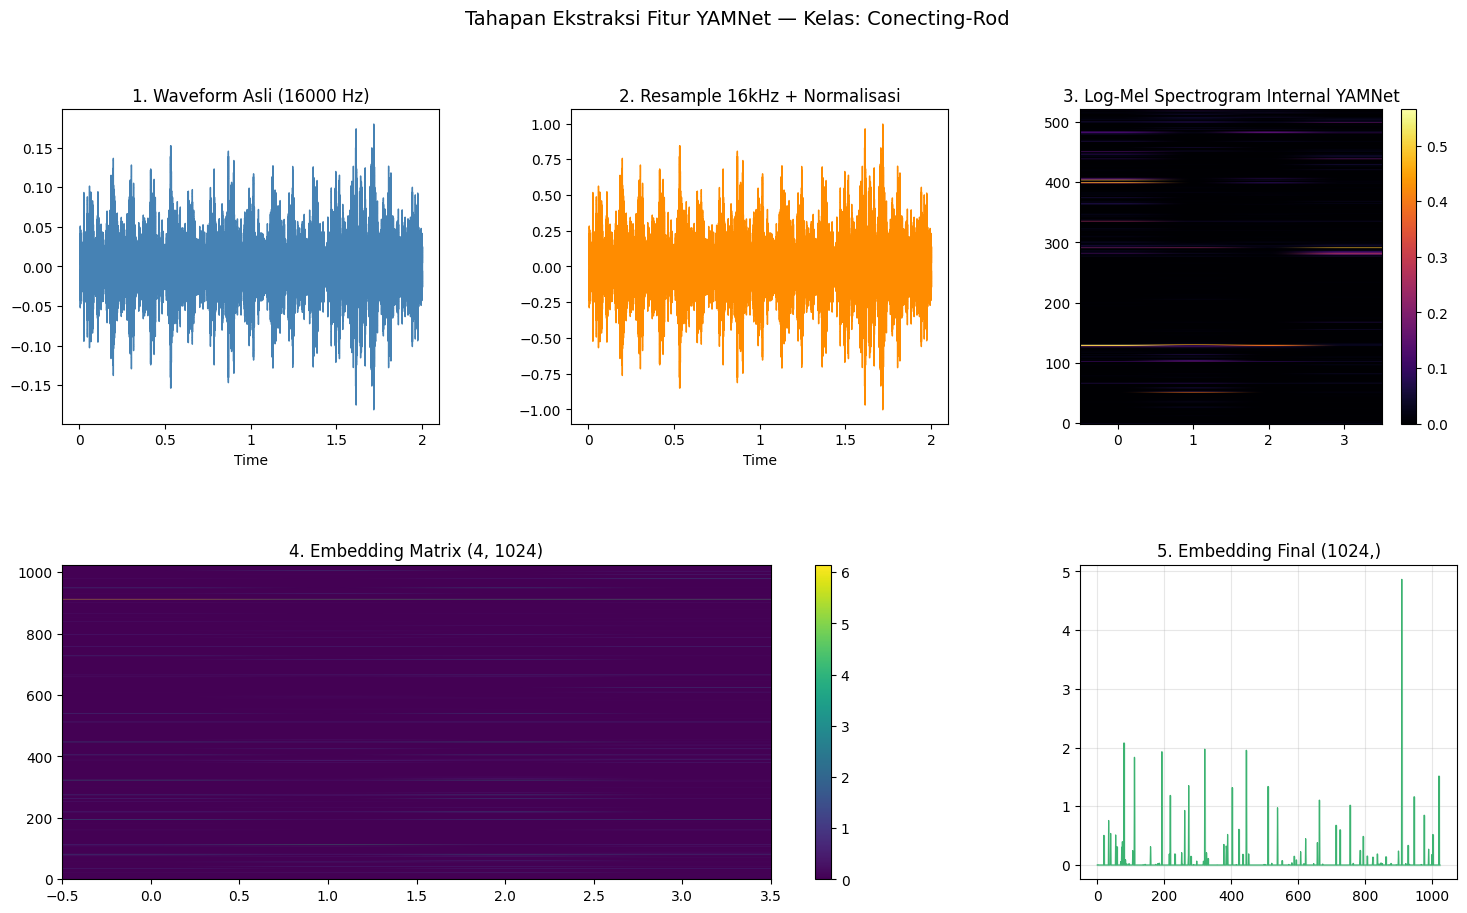

In [46]:


all_wavs = glob.glob(os.path.join(PATHS['aug_train'], '*', '*.wav'))
example_path = random.choice(all_wavs)
cls_name = os.path.basename(os.path.dirname(example_path))

wav_orig, sr_orig = librosa.load(example_path, sr=None, mono=True)
wav_16k, _ = librosa.load(example_path, sr=16000, mono=True)
wav_16k_norm = wav_16k / (np.max(np.abs(wav_16k)) + 1e-8)

log_mel_out, embeddings, _ = yamnet_model(wav_16k_norm)
emb_mean = np.mean(embeddings.numpy(), axis=0)

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Tahapan Ekstraksi Fitur YAMNet — Kelas: {cls_name}', fontsize=14)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
librosa.display.waveshow(wav_orig, sr=sr_orig, ax=ax1, color='steelblue')
ax1.set_title(f'1. Waveform Asli ({sr_orig} Hz)')

ax2 = fig.add_subplot(gs[0, 1])
librosa.display.waveshow(wav_16k_norm, sr=16000, ax=ax2, color='darkorange')
ax2.set_title('2. Resample 16kHz + Normalisasi')

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(log_mel_out.numpy().T, origin='lower', aspect='auto', cmap='inferno')
plt.colorbar(im3, ax=ax3); ax3.set_title('3. Log-Mel Spectrogram Internal YAMNet')

ax4 = fig.add_subplot(gs[1, 0:2])
im4 = ax4.imshow(embeddings.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(im4, ax=ax4); ax4.set_title(f'4. Embedding Matrix {embeddings.numpy().shape}')

ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(emb_mean, color='mediumseagreen', linewidth=0.8)
ax5.fill_between(range(len(emb_mean)), emb_mean, alpha=0.3, color='mediumseagreen')
ax5.set_title(f'5. Embedding Final {emb_mean.shape}'); ax5.grid(alpha=0.3)
plt.show()

In [47]:
emb = embeddings.numpy()

print("Min :", emb.min())
print("Max :", emb.max())
print("Mean:", emb.mean())
print("Std :", emb.std())

Min : 0.0
Max : 6.1405435
Mean: 0.040756952
Std : 0.2833836


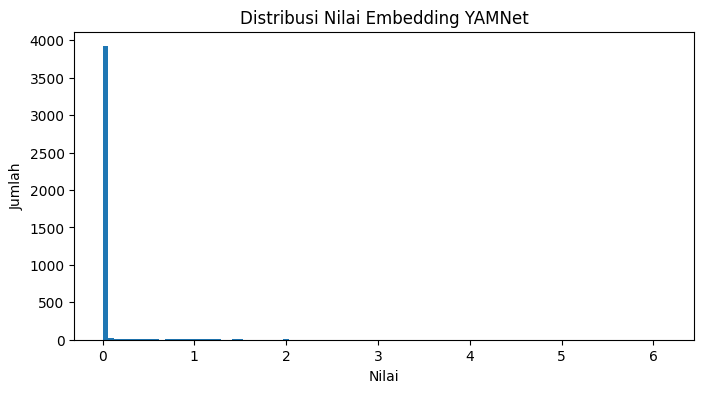

In [48]:
plt.figure(figsize=(8,4))
plt.hist(embeddings.numpy().flatten(), bins=100)
plt.title("Distribusi Nilai Embedding YAMNet")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.show()

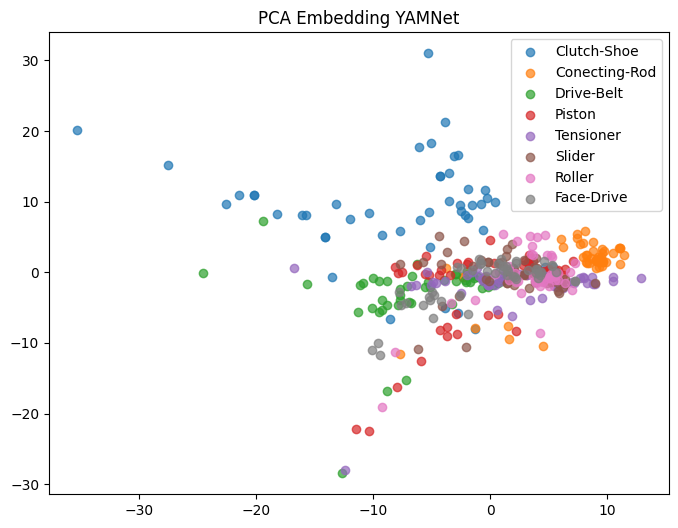

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_yn)

plt.figure(figsize=(8,6))

for i, cls in enumerate(CLASSES):
    idx = y_train_yn == i
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=cls,
        alpha=0.7
    )

plt.legend()
plt.title("PCA Embedding YAMNet")
plt.show()

Training YAMNet Dense Classifier...
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3550 - loss: 1.9509 - val_accuracy: 0.7895 - val_loss: 1.2693 - learning_rate: 3.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6825 - loss: 1.0259 - val_accuracy: 0.8421 - val_loss: 0.9433 - learning_rate: 3.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8450 - loss: 0.6698 - val_accuracy: 0.8421 - val_loss: 0.7899 - learning_rate: 3.0000e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.5074 - val_accuracy: 0.7895 - val_loss: 0.7201 - learning_rate: 3.0000e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9375 - loss: 0.3547 - val_accuracy: 0.8421 - val_loss: 0.6693 - learning_rate: 3.0000e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9475 - loss: 0.2687 - val_accuracy: 0.8421 - val_loss: 0.6505 - learning_rate: 3.0000e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━

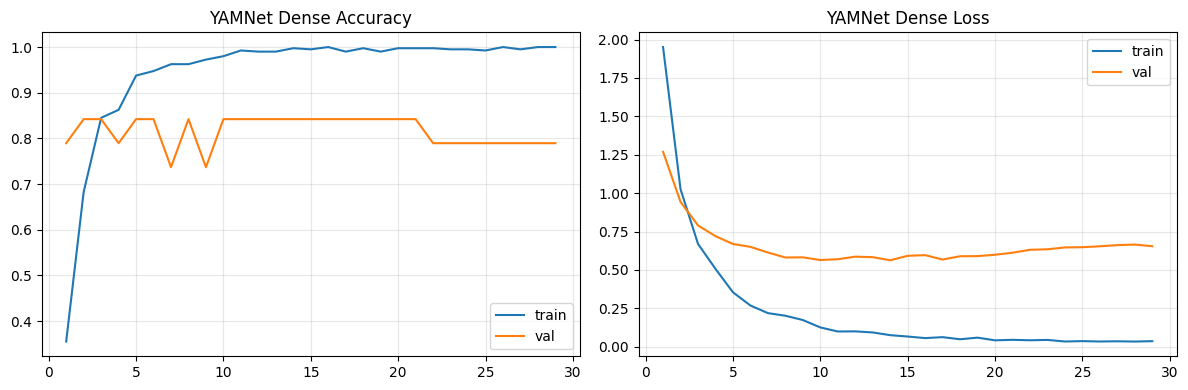

In [ ]:


def build_yamnet_classifier(n_classes):
    return Sequential([
        layers.Input(shape=(1024,)),
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ], 
    name="yamnet_dense")

model_yn = build_yamnet_classifier(len(CLASSES))
model_yn.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_yn = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Training YAMNet Dense Classifier...")
history_yn = model_yn.fit(
    X_train_yn, y_train_yn,
    validation_data=(X_val_yn, y_val_yn),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_yn, verbose=1
)

loss, acc = model_yn.evaluate(X_test_yn, y_test_yn, verbose=0)
print(f"\n---> Akurasi YAMNet Dense pada Test Set: {acc*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history_yn.history['loss']) + 1)
ax[0].plot(ep, history_yn.history['accuracy'],     label='train')
ax[0].plot(ep, history_yn.history['val_accuracy'], label='val')
ax[0].set_title('YAMNet Dense Accuracy'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history_yn.history['loss'],     label='train')
ax[1].plot(ep, history_yn.history['val_loss'], label='val')
ax[1].set_title('YAMNet Dense Loss'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [51]:
from sklearn.metrics import classification_report

y_pred = np.argmax(
    model_yn.predict(X_test_yn),
    axis=1
)

print(
    classification_report(
        y_test_yn,
        y_pred,
        target_names=CLASSES
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
               precision    recall  f1-score   support

  Clutch-Shoe       1.00      0.33      0.50         3
Conecting-Rod       1.00      1.00      1.00         3
   Drive-Belt       0.80      1.00      0.89         4
       Piston       0.00      0.00      0.00         1
    Tensioner       1.00      1.00      1.00         2
       Slider       0.40      1.00      0.57         2
       Roller       0.75      0.86      0.80         7
   Face-Drive       0.00      0.00      0.00         2

     accuracy                           0.75        24
    macro avg       0.62      0.65      0.60        24
 weighted avg       0.72      0.75      0.70        24



### SVM

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_svm = scaler.fit_transform(X_train_yn)
X_val_svm = scaler.transform(X_val_yn)
X_test_svm = scaler.transform(X_test_yn)

In [58]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

print("Training SVM...")

svm_model.fit(X_train_svm, y_train_yn)

val_pred = svm_model.predict(X_val_svm)
val_acc = accuracy_score(y_val_yn, val_pred)

print(f"Validation Accuracy : {val_acc*100:.2f}%")

Training SVM...
Validation Accuracy : 78.95%


In [59]:
test_pred = svm_model.predict(X_test_svm)

test_acc = accuracy_score(y_test_yn, test_pred)

print(f"\nTest Accuracy : {test_acc*100:.2f}%")


Test Accuracy : 79.17%


In [60]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_yn,
        test_pred,
        target_names=CLASSES
    )
)

               precision    recall  f1-score   support

  Clutch-Shoe       0.50      0.33      0.40         3
Conecting-Rod       1.00      1.00      1.00         3
   Drive-Belt       0.80      1.00      0.89         4
       Piston       0.00      0.00      0.00         1
    Tensioner       1.00      1.00      1.00         2
       Slider       0.67      1.00      0.80         2
       Roller       0.78      1.00      0.88         7
   Face-Drive       0.00      0.00      0.00         2

     accuracy                           0.79        24
    macro avg       0.59      0.67      0.62        24
 weighted avg       0.69      0.79      0.73        24



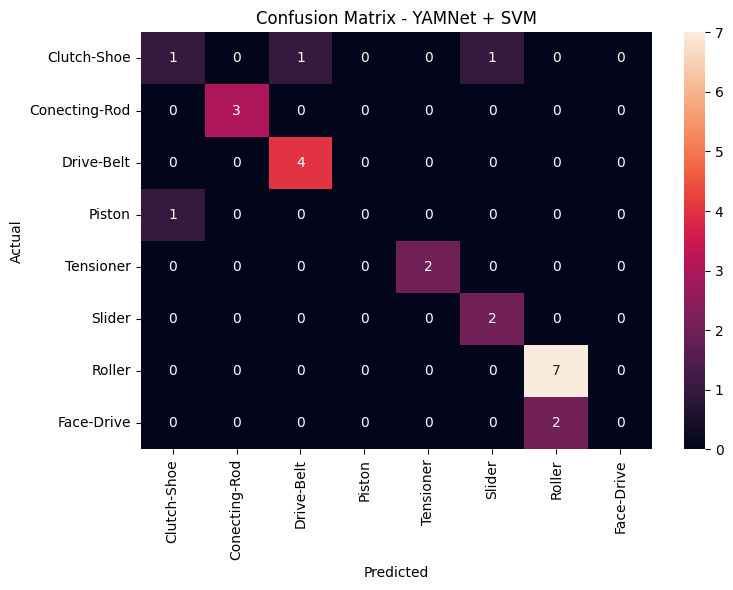

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_yn, test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + SVM")

plt.tight_layout()
plt.show()

### Random Forest

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_rf = scaler.fit_transform(X_train_yn)
X_val_rf = scaler.transform(X_val_yn)
X_test_rf = scaler.transform(X_test_yn)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train_rf, y_train_yn)

val_pred_rf = rf_model.predict(X_val_rf)

val_acc_rf = accuracy_score(y_val_yn, val_pred_rf)

print(f"Validation Accuracy RF : {val_acc_rf*100:.2f}%")

test_pred_rf = rf_model.predict(X_test_svm)

test_acc_rf = accuracy_score(y_test_yn, test_pred_rf)

print(f"Test Accuracy RF : {test_acc_rf*100:.2f}%")

Training Random Forest...
Validation Accuracy RF : 89.47%
Test Accuracy RF : 83.33%


In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_yn,
        test_pred_rf,
        target_names=CLASSES
    )
)

               precision    recall  f1-score   support

  Clutch-Shoe       1.00      0.33      0.50         3
Conecting-Rod       1.00      1.00      1.00         3
   Drive-Belt       1.00      1.00      1.00         4
       Piston       1.00      1.00      1.00         1
    Tensioner       1.00      1.00      1.00         2
       Slider       0.67      1.00      0.80         2
       Roller       0.70      1.00      0.82         7
   Face-Drive       0.00      0.00      0.00         2

     accuracy                           0.83        24
    macro avg       0.80      0.79      0.77        24
 weighted avg       0.80      0.83      0.79        24



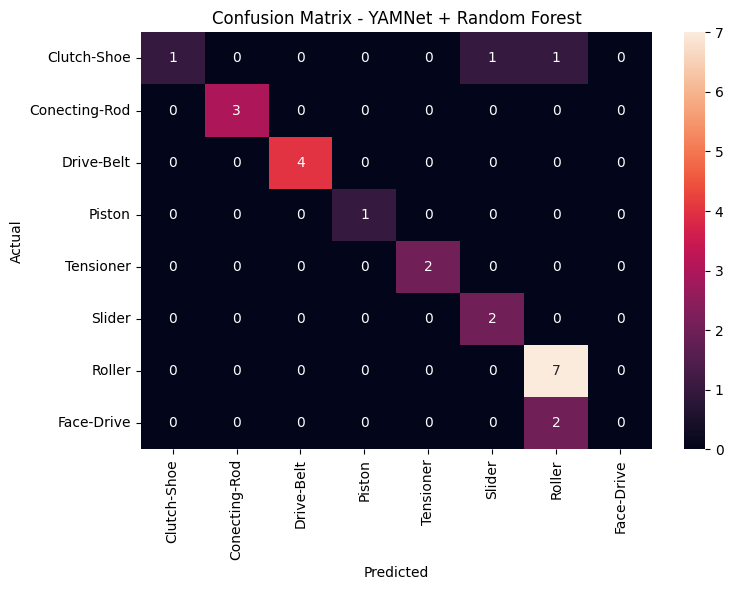

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test_yn, test_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + Random Forest")

plt.tight_layout()
plt.show()

### YAMNet + Bidirectional LSTM

Menggunakan embedding **per-frame** `(N_frames, 1024)` dari YAMNet sebagai input ke Bi-LSTM.
Berbeda dengan Dense Classifier yang meratakan frame, LSTM **membaca urutan temporal** sehingga mampu menangkap pola periodik suara mesin motor.

In [52]:
# # ── YAMNet + LSTM: Ekstraksi Embedding Per-Frame ────────────────────────
# # Berbeda dengan Dense Classifier yang menggunakan Mean Pooling (1024,),
# # LSTM membutuhkan data urutan per-frame: (N_frames, 1024)

# import numpy as np
# import librosa
# import glob
# import os

# # 1. Muat model YAMNet dari TF Hub
# print("Memuat model YAMNet dari TF Hub...")
# yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
# print("YAMNet berhasil dimuat!")


# YAMNET_SEQ_FEAT = {
#     "train": (os.path.join(PATHS['features'], 'X_train_yamnet_seq.npy'), os.path.join(PATHS['features'], 'y_train_yamnet_seq.npy')),
#     "val"  : (os.path.join(PATHS['features'], 'X_val_yamnet_seq.npy'),   os.path.join(PATHS['features'], 'y_val_yamnet_seq.npy')),
#     "test" : (os.path.join(PATHS['features'], 'X_test_yamnet_seq.npy'),  os.path.join(PATHS['features'], 'y_test_yamnet_seq.npy')),
# }
# SRC = {"train": PATHS['aug_train'], "val": PATHS['prep_val'], "test": PATHS['prep_test']}

# # Tentukan N_frames secara otomatis dari 1 file contoh
# _sample_wav = glob.glob(os.path.join(PATHS['aug_train'], '*', '*.wav'))[0]
# _sample_audio, _ = librosa.load(_sample_wav, sr=16000, mono=True)
# _sample_audio = _sample_audio / (np.max(np.abs(_sample_audio)) + 1e-8)
# _, _emb, _ = yamnet_model(_sample_audio)
# N_FRAMES = _emb.numpy().shape[0]
# print(f"N_frames per sampel: {N_FRAMES} (setiap file 3 detik menghasilkan {N_FRAMES} frame @ YAMNet)")

# def extract_yamnet_sequences(data_dir, n_frames):
  
#     X, y = [], []
#     for lbl, cls in enumerate(CLASSES):
#         files = glob.glob(os.path.join(data_dir, cls, '*.wav'))
#         for f in files:
#             wav, _ = librosa.load(f, sr=16000, mono=True)
#             wav = wav / (np.max(np.abs(wav)) + 1e-8)
#             _, embeddings, _ = yamnet_model(wav)
#             emb = embeddings.numpy()  # (N_frames, 1024)
            
#             # Pastikan N_frames konsisten (pad atau potong)
#             if emb.shape[0] < n_frames:
#                 pad_width = n_frames - emb.shape[0]
#                 emb = np.pad(emb, ((0, pad_width), (0, 0)))
#             else:
#                 emb = emb[:n_frames]
                
#             X.append(emb)
#             y.append(lbl)
#     return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

# print("\nEkstraksi embedding sekuensial YAMNet...")
# for subset, (xp, yp) in YAMNET_SEQ_FEAT.items():
#     if os.path.exists(xp):
#         print(f"  {subset:<6}: cache ditemukan, skip")
#     else:
#         print(f"  {subset:<6}: mengekstrak (membutuhkan beberapa menit)...")
#         X, y = extract_yamnet_sequences(SRC[subset], N_FRAMES)
#         np.save(xp, X); np.save(yp, y)
#         print(f"  {subset:<6}: {X.shape} tersimpan")

# X_train_seq = np.load(YAMNET_SEQ_FEAT['train'][0]); y_train_seq = np.load(YAMNET_SEQ_FEAT['train'][1])
# X_val_seq   = np.load(YAMNET_SEQ_FEAT['val'][0]);   y_val_seq   = np.load(YAMNET_SEQ_FEAT['val'][1])
# X_test_seq  = np.load(YAMNET_SEQ_FEAT['test'][0]);  y_test_seq  = np.load(YAMNET_SEQ_FEAT['test'][1])

# print(f"\nX_train_seq : {X_train_seq.shape}  (N_samples, N_frames, 1024)")
# print(f"X_val_seq   : {X_val_seq.shape}")
# print(f"X_test_seq  : {X_test_seq.shape}")

In [53]:
# # ── YAMNet + Bidirectional LSTM: Arsitektur & Training ──────────────────
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# import matplotlib.pyplot as plt

# def build_yamnet_lstm(n_frames, n_classes):
#     inputs = layers.Input(shape=(n_frames, 1024))
    
#     # Bi-LSTM Layer 1: membaca urutan frame maju & mundur sekaligus
#     x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
#     x = layers.Dropout(0.3)(x)
    
#     # Bi-LSTM Layer 2: merangkum konteks keseluruhan
#     x = layers.Bidirectional(layers.LSTM(64))(x)
#     x = layers.Dropout(0.3)(x)
    
#     # Classifier Head
#     x = layers.Dense(64, activation='relu')(x)
#     outputs = layers.Dense(n_classes, activation='softmax')(x)
    
#     return models.Model(inputs, outputs, name='yamnet_bilstm')

# model_lstm = build_yamnet_lstm(X_train_seq.shape[1], len(CLASSES))
# model_lstm.summary()

# model_lstm.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# callbacks_lstm = [
#     EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# ]

# print("\nTraining YAMNet + Bi-LSTM...")
# history_lstm = model_lstm.fit(
#     X_train_seq, y_train_seq,
#     validation_data=(X_val_seq, y_val_seq),
#     epochs=100,
#     batch_size=16,
#     callbacks=callbacks_lstm,
#     verbose=1
# )

# loss_lstm, acc_lstm = model_lstm.evaluate(X_test_seq, y_test_seq, verbose=0)
# print(f"\n---> Akurasi YAMNet + Bi-LSTM pada Test Set: {acc_lstm*100:.2f}%")

# # Learning Curve
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# ep = range(1, len(history_lstm.history['loss']) + 1)
# ax[0].plot(ep, history_lstm.history['accuracy'],     label='train')
# ax[0].plot(ep, history_lstm.history['val_accuracy'], label='val')
# ax[0].set_title('YAMNet + Bi-LSTM Accuracy'); ax[0].legend(); ax[0].grid(alpha=0.3)
# ax[1].plot(ep, history_lstm.history['loss'],     label='train')
# ax[1].plot(ep, history_lstm.history['val_loss'], label='val')
# ax[1].set_title('YAMNet + Bi-LSTM Loss'); ax[1].legend(); ax[1].grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

## 11. Inference Pipeline

Pengujian model pada data raw `.wav`.

In [54]:
def predict_single_audio(wav_path, model):
    """Khusus Model Spectrogram (CNN & MobileNetV2)"""
    y, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    peak  = np.max(np.abs(y))
    y = y / peak if peak > 0 else y
    
    audio_len = len(y)
    if audio_len < TARGET_SAMPLES:
        y = np.tile(y, int(np.ceil(TARGET_SAMPLES / audio_len)))
        
    chunks = [y[i:i+TARGET_SAMPLES]
              for i in range(0, len(y)-TARGET_SAMPLES+1, STRIDE_SAMPLES)
              if len(y[i:i+TARGET_SAMPLES]) == TARGET_SAMPLES]
              
    if not chunks:
        chunks = [y[:TARGET_SAMPLES]]
        
    features = []
    for chunk in chunks:
        mel = librosa.feature.melspectrogram(
            y=chunk, sr=TARGET_SR, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS
        )
        db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
        features.append(db)
        
    X_infer = np.array(features)
    X_infer = X_infer[..., np.newaxis] 
    
    mn = X_infer.min(axis=(1,2,3), keepdims=True)
    mx = X_infer.max(axis=(1,2,3), keepdims=True)
    X_infer = (X_infer - mn) / (mx - mn + 1e-8)
    
    preds = model.predict(X_infer, verbose=0)
    pred_classes = preds.argmax(axis=1)
    
    unique, counts = np.unique(pred_classes, return_counts=True)
    final_class_idx = unique[np.argmax(counts)]
    return CLASSES[final_class_idx]


def predict_single_yamnet(wav_path, classifier_model):
    """Khusus Model YAMNet (Waveform ke Embedding 1024)"""
    y, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    peak  = np.max(np.abs(y))
    y = y / peak if peak > 0 else y
    
    audio_len = len(y)
    if audio_len < TARGET_SAMPLES:
        y = np.tile(y, int(np.ceil(TARGET_SAMPLES / audio_len)))
        
    chunks = [y[i:i+TARGET_SAMPLES]
              for i in range(0, len(y)-TARGET_SAMPLES+1, STRIDE_SAMPLES)
              if len(y[i:i+TARGET_SAMPLES]) == TARGET_SAMPLES]
              
    if not chunks:
        chunks = [y[:TARGET_SAMPLES]]
        
    features = []
    for chunk in chunks:
        # Ekstrak Embedding dari model YAMNet asli
        _, embeddings, _ = yamnet_model(chunk)
        emb_mean = np.mean(embeddings.numpy(), axis=0)
        features.append(emb_mean)
        
    X_infer = np.array(features) # (N_chunks, 1024)
    
    preds = classifier_model.predict(X_infer, verbose=0)
    pred_classes = preds.argmax(axis=1)
    
    unique, counts = np.unique(pred_classes, return_counts=True)
    final_class_idx = unique[np.argmax(counts)]
    return CLASSES[final_class_idx]


print("--- Inference Test (YAMNet) ---")
test_dir = os.path.join(PATHS['split_orig'], "test")
all_test_files = glob.glob(os.path.join(test_dir, "*", "*.wav"))

if all_test_files:
    sample_files = random.sample(all_test_files, min(10, len(all_test_files)))
    
    for f in sample_files:
        true_label = os.path.basename(os.path.dirname(f))
        file_name = os.path.basename(f)
        
        # ---> MENGGUNAKAN FUNGSI YAMNET <---
        predicted_label = predict_single_yamnet(f, model_yn) 
        
        status = "OK" if true_label == predicted_label else "FAIL"
        print(f"[{status}] {file_name:<15} | True: {true_label:<15} | Pred: {predicted_label:<15}")
else:
    print("Tidak ditemukan file audio di folder test.")


--- Inference Test (YAMNet) ---
[OK] slider-002.wav  | True: Slider          | Pred: Slider         
[FAIL] clutch-shoe-010.wav | True: Clutch-Shoe     | Pred: Roller         
[OK] roller-003.wav  | True: Roller          | Pred: Roller         
[FAIL] piston-001.wav  | True: Piston          | Pred: Slider         
[FAIL] drive-belt-018.wav | True: Drive-Belt      | Pred: Slider         
[OK] roller-001.wav  | True: Roller          | Pred: Roller         
[FAIL] drive-belt-005.wav | True: Drive-Belt      | Pred: Slider         
[FAIL] tensioner-004.wav | True: Tensioner       | Pred: Slider         
[OK] conecting-rod-007.wav | True: Conecting-Rod   | Pred: Conecting-Rod  
[FAIL] clutch-shoe-013.wav | True: Clutch-Shoe     | Pred: Slider         
